Phantom angles = 8760
tumor angles = 3230


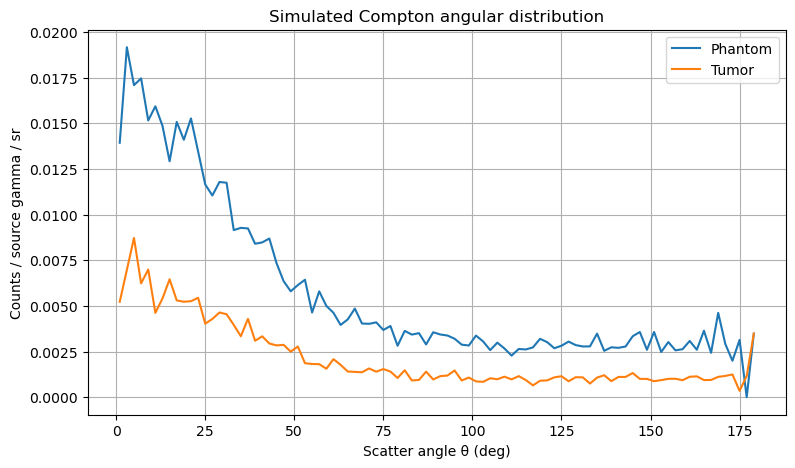

In [7]:
import ROOT
import numpy as np
import matplotlib.pyplot as plt

root_file = "sucrose.root"
tree_name = "t"

# Set your real volume IDs
Phantom = 3
tumor = 2

compton_code = 2013

# Incident gamma direction: source at y=20 cm toward -y
kin = np.array([0.0, -1.0, 0.0])

f = ROOT.TFile.Open(root_file)
if not f or f.IsZombie():
    raise RuntimeError("Could not open ROOT file")

t = f.Get(tree_name)
if not t:
    raise RuntimeError("Could not find tree t")

angles_Phantom = []
angles_tumor = []

for event in t:
    n = min(len(event.vlm), len(event.pdg), len(event.pro))

    for i in range(n):

        if event.pdg[i] != 22:
            continue

        if event.pro[i] != compton_code:
            continue

        if event.vlm[i] not in [Phantom, tumor]:
            continue

        # Check if px, py, pz exist in your tree
        p = np.array([event.px[i], event.py[i], event.pz[i]])
        norm = np.linalg.norm(p)

        if norm == 0:
            continue

        kout = p / norm

        cos_theta = np.dot(kin, kout)
        cos_theta = np.clip(cos_theta, -1.0, 1.0)

        theta = np.degrees(np.arccos(cos_theta))

        if event.vlm[i] == Phantom:
            angles_Phantom.append(theta)

        elif event.vlm[i] == tumor:
            angles_tumor.append(theta)

print("Phantom angles =", len(angles_Phantom))
print("tumor angles =", len(angles_tumor))

bins = np.linspace(0, 180, 91)
centers = 0.5 * (bins[:-1] + bins[1:])

Phantom_counts, _ = np.histogram(angles_Phantom, bins=bins)
tumor_counts, _ = np.histogram(angles_tumor, bins=bins)

theta_rad1 = np.radians(bins[:-1])
theta_rad2 = np.radians(bins[1:])
dOmega = 2 * np.pi * (np.cos(theta_rad1) - np.cos(theta_rad2))

N_events = t.GetEntries()

Phantom_rate = Phantom_counts / (N_events * dOmega)
tumor_rate = tumor_counts / (N_events * dOmega)

plt.figure(figsize=(9, 5))
plt.plot(centers, Phantom_rate, label="Phantom")
plt.plot(centers, tumor_rate, label="Tumor")
plt.xlabel("Scatter angle θ (deg)")
plt.ylabel("Counts / source gamma / sr")
plt.title("Simulated Compton angular distribution")
plt.legend()
plt.grid(True)
plt.show()